In [103]:
import sisl 
import matplotlib.pyplot as plt
from pathlib import Path
import numpy as np
from ase.visualize import view

In [104]:
def showidx(geom):
    x,y,z = geom.xyz.T
    
    fig,ax = plt.subplots()
    ax.scatter(x, y, c='k')
    for atom in range(geom.na):
        ax.annotate(text=atom, xy=(x[atom], y[atom]))
    return fig, ax
    

In [105]:
labels = ['zigzag', 'armchair']

In [115]:
lab = labels[1]
Nw = 10

outdir = Path(f'./TBT_{lab}')
outdir = Path(f'./TBT-Nw{Nw}-{lab}')
outdir.exists()

True

In [116]:
SEfile = outdir / f'{lab}.TBT.SE.nc'
SEfile = outdir / f'{lab}.TBT.SE.nc'
tbtse = sisl.io.get_sile(SEfile)
En = tbtse.E
kpts = tbtse.k
wk = tbtse.wk
eta = tbtse.eta()
a_dev = tbtse.a_dev

def GetSigma(e, elec=0, k=[0.,0.,0.,]):
    tmp = tbtse.self_energy(elec=0,E=e,k=k,sort=True).data
    pvt = tbtse.pivot(elec=elec, in_device=True, sort=True).reshape(-1, 1)  # and downfolded to smaller region
    no_d = tbtse.no_d ## down-folded region size
    #print(tmp[0].dtype)
    ZeroMat = np.eye(no_d, dtype=np.complex128)
    Sigma = ZeroMat.copy()  # transform to original orbit
    Sigma[pvt, pvt.T] += tmp  # transform to original orbital-index using pvt arrays.
    return Sigma


E = 0.1
left_se = GetSigma(E, elec=0)
right_se = GetSigma(E, elec=1)

info:0: SislInfo:

tbtsencSileTBtrans requesting energy 0.10000 eV, found 0.10500 eV as the closest energy!

info:0: SislInfo:

tbtsencSileTBtrans requesting energy 0.10000 eV, found 0.10500 eV as the closest energy!



In [117]:
excess_atoms = np.delete(np.arange(tbtse.na), [tbtse.a_dev, tbtse.a_elec(0), tbtse.a_elec(1)])
style = [
    {'atoms':tbtse.a_dev, 'color':'yellow'},
    {'atoms':tbtse.a_elec(0), 'color':'blue'},
    {'atoms':tbtse.a_elec(1), 'color':'red'},
    {'atoms':excess_atoms, 'color':'black'},
]

tbtse.geometry.plot(axes='xy', atoms_style=style, backend='plotly')

slice(4, 36, 1) slice(44, 76, 1) slice(84, 116, 1)
(40, 40)


info:0: SislInfo:

tbtsencSileTBtrans requesting energy 0.00000 eV, found 0.00500 eV as the closest energy!

info:0: SislInfo:

tbtsencSileTBtrans requesting energy 0.00000 eV, found 0.00500 eV as the closest energy!



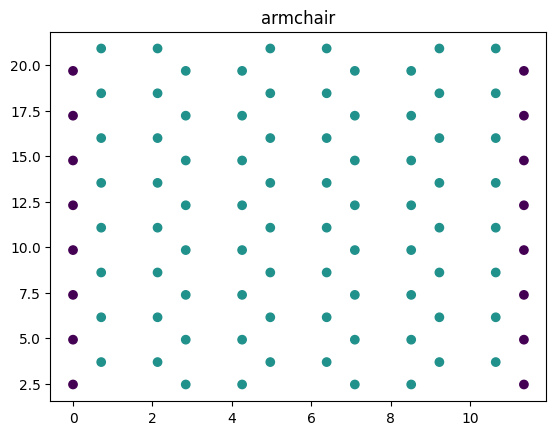

In [145]:
num_atoms = 4 * 4
ND = tbtse.na
NL = tbtse.na_down(0)
NR = tbtse.na_down(1)
idxL = slice(NL//2-num_atoms, NL//2+num_atoms, 1)
idxD = slice(ND//2-num_atoms, ND//2+num_atoms, 1)
idxR = slice(ND-NR//2-num_atoms, ND-NR//2+num_atoms, 1)
print(idxL, idxD, idxR)


xyz = tbtse.xyz

E = 0.0
kpts = [0., 0., 0.]
site0 = NL//2
site1 = ND-NR//2
coup0 = np.imag(GetSigma(e=E, elec=0, k=kpts))
coup1 = np.imag(GetSigma(e=E, elec=1, k=kpts))
print(coup1.shape)

vmax = np.max(np.abs([coup0, coup1]))
vmin = -vmax
cmap='viridis'
fig, ax = plt.subplots()
ax.set_title(lab)
ax.scatter(x=xyz[idxL, 0], y=xyz[idxL, 1], label='left', c=np.diag(coup0)[idxL], vmin=vmin, vmax=vmax, cmap=cmap)
ax.scatter(x=xyz[idxD, 0], y=xyz[idxD, 1], label='device', c=np.zeros(shape=(2*num_atoms)), vmin=vmin, vmax=vmax, cmap=cmap)
ax.scatter(x=xyz[idxR, 0], y=xyz[idxR, 1], label='Right', c=np.diag(coup1)[idxL], vmin=vmin, vmax=vmax, cmap=cmap)
# ax.axis('square')

slice(0, 40, 1) slice(40, 80, 1) slice(80, 120, 1)


info:0: SislInfo:

tbtsencSileTBtrans requesting energy 0.00000 eV, found 0.00500 eV as the closest energy!

info:0: SislInfo:

tbtsencSileTBtrans requesting energy 0.00000 eV, found 0.00500 eV as the closest energy!

info:0: SislInfo:

tbtsencSileTBtrans requesting energy 0.00000 eV, found 0.00500 eV as the closest energy!

info:0: SislInfo:

tbtsencSileTBtrans requesting energy 0.00000 eV, found 0.00500 eV as the closest energy!



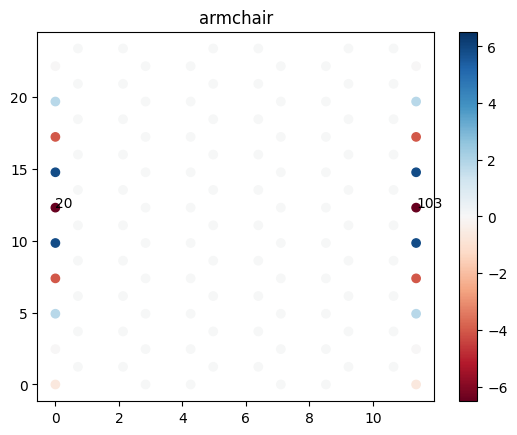

In [147]:
num_atoms = 4 * 5
ND = tbtse.na
NL = tbtse.na_down(0)
NR = tbtse.na_down(1)
idxL = slice(NL//2-num_atoms, NL//2+num_atoms, 1)
idxD = slice(ND//2-num_atoms, ND//2+num_atoms, 1)
idxR = slice(ND-NR//2-num_atoms, ND-NR//2+num_atoms, 1)
print(idxL, idxD, idxR)


xyz = tbtse.xyz

E = 0.0
kpts = [0., 0., 0.]
site0 = NL//2
site1 = ND-NR//2 +3
coup0 = np.imag(GetSigma(e=E, elec=0, k=kpts))
coup1 = np.imag(GetSigma(e=E, elec=1, k=kpts))

Broadening = np.zeros(shape=(ND, ND), dtype=np.complex128)
Broadening[idxL, idxL] += GetSigma(e=E, elec=0, k=kpts)
Broadening[idxR, idxR] += GetSigma(e=E, elec=1, k=kpts)

vmax = np.max(np.abs([coup0, coup1]))
vmin = -vmax
cmap='RdBu'
fig, ax = plt.subplots()
ax.set_title(lab)
# ax.scatter(x=xyz[idxL, 0], y=xyz[idxL, 1], label='left', c=coup0[idxL, site0], vmin=vmin, vmax=vmax, cmap=cmap)
# ax.scatter(x=xyz[idxD, 0], y=xyz[idxD, 1], label='device', c=np.zeros(shape=(2*num_atoms)), vmin=vmin, vmax=vmax, cmap=cmap)
# ax.scatter(x=xyz[idxR, 0], y=xyz[idxR, 1], label='Right', c=coup1[idxL, site1], vmin=vmin, vmax=vmax, cmap=cmap)
ax.scatter(x=xyz[:ND//2, 0], y=xyz[:ND//2, 1], c=np.imag(Broadening[:ND//2, site0]), vmin=vmin, vmax=vmax, cmap=cmap)
sc = ax.scatter(x=xyz[ND//2:, 0], y=xyz[ND//2:, 1], c=np.imag(Broadening[ND//2:, site1]), vmin=vmin, vmax=vmax, cmap=cmap)
for atom in [site0, site1]:
    ax.annotate(text=atom, xy=(xyz[atom, :2]))
    
fig.colorbar(sc)
# ax.axis('square')

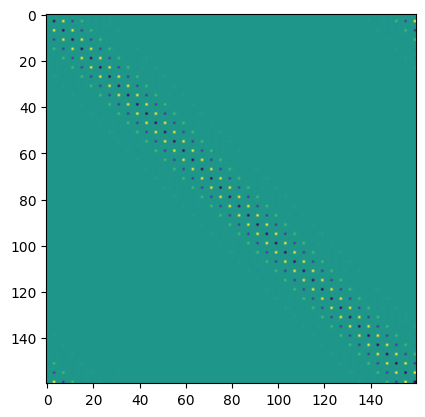

In [99]:
plt.imshow(coup1)

(-10.0, 25.999999999999943)

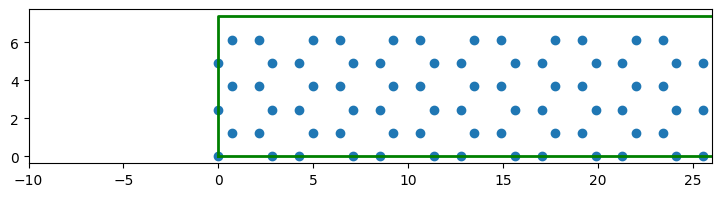

In [ ]:
trunc = -1
geom = tbtse.read_geometry()
x,y,_ = geom.xyz[:trunc].T
A, B, C = geom.cell[:2, :].T

fig, ax = plt.subplots(figsize=(20,2))
ax.scatter(x,y)
UC_x, UC_y = np.array([A-A, A, A+B, B, B-B]).T
ax.plot(UC_x, UC_y, color='g', lw=2)
ax.axis('scaled')
ax.set_xlim((A.min()- 10, A.max() -400))

In [ ]:
path = Path('./TBT_zigzag')
Hfile = path / 'zigzag.TBT.nc'
Hfile.exists()

True

In [ ]:
H_dev = sisl.get_sile(Hfile)
H_dev.read_geometry().plot(axes='xy')

In [66]:
Nw = 10
Nl = 3
kind = "armchair"

if kind == 'armchair':
    gr = sisl.geom.graphene(1.42, orthogonal=True).tile(Nw, 1).tile(Nl, 0)
elif kind == 'zigzag':
    gr = sisl.geom.graphene(1.42, orthogonal=True).tile(Nw, 0).tile(Nl,1)

style = [
    {'atoms':range(4*Nw), 'color':'red'},
    {'atoms':range(-4*Nw, 0), 'color':'blue'}
]
fig = gr.plot(axes='xy', atoms_style=style)
fig

In [ ]:
view(gr.to.ase())

[1, 10, 1]
